In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from matplotlib import pyplot as plt

In [2]:
class VAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super(VAE, self).__init__()

        # Encoder
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        # Decoder
        self.fc2 = nn.Linear(latent_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + eps * std
        return z

    def decode(self, z):
        h = F.relu(self.fc2(z))
        x_recon = torch.sigmoid(self.fc3(h))
        return x_recon

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar


In [3]:
def vae_loss(recon_x, x, mu, logvar):
    # Reconstruction loss
    bce = F.binary_cross_entropy(recon_x, x, reduction='sum')

    # KL divergence
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    return bce + kld, bce, kld


In [4]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = VAE().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

cpu


In [68]:
num_epochs = 30
train_losses = []
bce_losses = []
kld_losses = []

In [69]:
train_losses = []
bce_losses = []
kld_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    running_bce = 0
    running_kld = 0

    for x, _ in train_loader:

        x = x.view(-1, 784).to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        loss, bce, kld = vae_loss(recon, x, mu, logvar)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_bce += bce.item()
        running_kld += kld.item()

    train_losses.append(running_loss / len(train_loader))
    bce_losses.append(running_bce / len(train_loader))
    kld_losses.append(running_kld / len(train_loader))

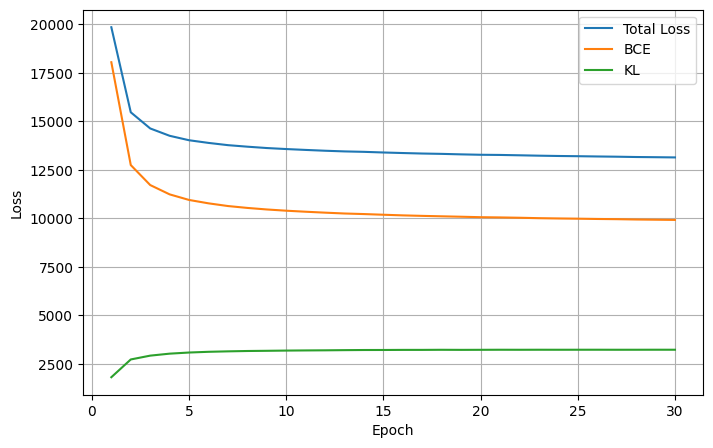

In [70]:
plt.figure(figsize=(8,5))

plt.plot(range(1, num_epochs+1), train_losses, label="Total Loss")
plt.plot(range(1, num_epochs+1), bce_losses, label="BCE")
plt.plot(range(1, num_epochs+1), kld_losses, label="KL")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [71]:
model.eval()

with torch.no_grad():

    images, _ = next(iter(test_loader))

    images = images.view(-1,784).to(device)

    recon, _, _ = model(images)

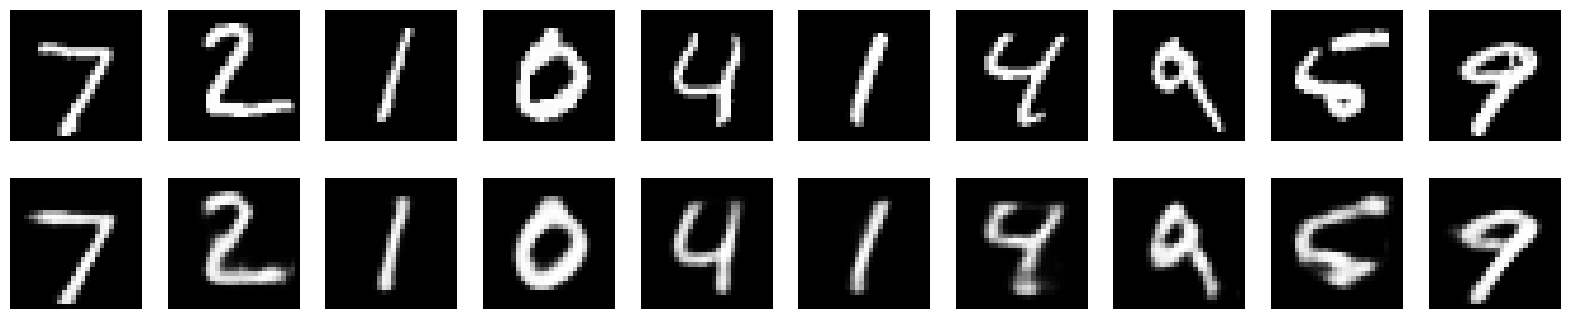

In [72]:
n = 10

plt.figure(figsize=(20,4))

for i in range(n):

    # تصویر واقعی
    plt.subplot(2,n,i+1)
    plt.imshow(images[i].cpu().view(28,28), cmap="gray")
    plt.axis("off")

    # تصویر بازسازی شده
    plt.subplot(2,n,i+n+1)
    plt.imshow(recon[i].cpu().view(28,28), cmap="gray")
    plt.axis("off")

plt.show()

In [73]:
model.eval()

with torch.no_grad():

    z = torch.randn(10,20).to(device)

    generated = model.decode(z)

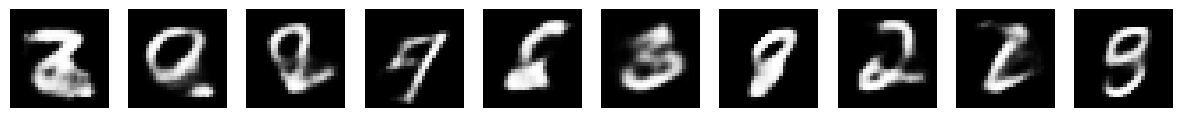

In [74]:
plt.figure(figsize=(15,2))

for i in range(10):

    plt.subplot(1,10,i+1)

    plt.imshow(generated[i].cpu().view(28,28), cmap="gray")

    plt.axis("off")

plt.show()

In [75]:
latent = []

labels = []

model.eval()

with torch.no_grad():

    for x,y in test_loader:

        x = x.view(-1,784).to(device)

        mu, logvar = model.encode(x)

        latent.append(mu.cpu())

        labels.append(y)

In [76]:
latent = torch.cat(latent)

labels = torch.cat(labels)

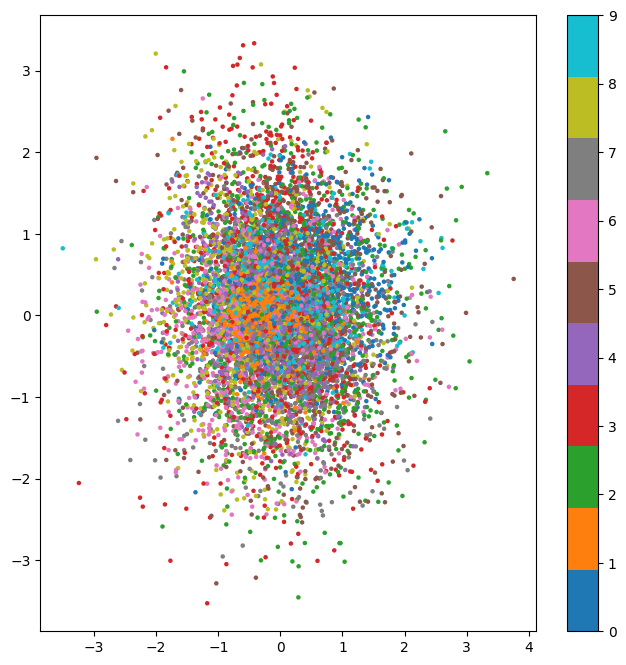

In [77]:
plt.figure(figsize=(8,8))

plt.scatter(latent[:,0],
            latent[:,1],
            c=labels,
            s=5,
            cmap="tab10")

plt.colorbar()

plt.show()

In [78]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2)

latent_2d = tsne.fit_transform(latent)

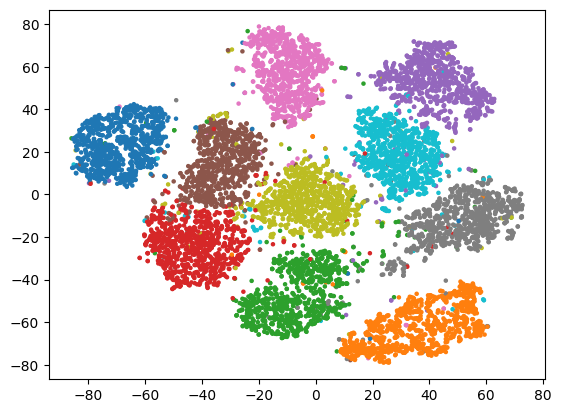

In [79]:
plt.scatter(latent_2d[:,0],
            latent_2d[:,1],
            c=labels,
            s=5,
            cmap="tab10")

In [80]:
# def weight_reset(m):
#     if hasattr(m, 'reset_parameters'):
#         m.reset_parameters()
# model.apply(weight_reset)


In [81]:
class CVAE(nn.Module):
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20, num_classes=10):
        super(CVAE, self).__init__()
        self.num_classes = num_classes

        self.fc1 = nn.Linear(input_dim + num_classes, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

        self.fc2 = nn.Linear(latent_dim + num_classes, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, input_dim)

    def encode(self, x, y):
        x = torch.cat([x, y], dim=1)
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z, y):
        z = torch.cat([z, y], dim=1)
        h = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x, y):
        mu, logvar = self.encode(x, y)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z, y)
        return recon_x, mu, logvar


In [82]:
def one_hot(labels, num_classes=10):
    return F.one_hot(labels, num_classes=num_classes).float()


In [ ]:
model = CVAE(input_dim=784, hidden_dim=400, latent_dim=20, num_classes=10).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
train_losses = []
bce_losses = []
kld_losses = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    running_bce = 0
    running_kld = 0

    for x, y in train_loader:

        x = x.view(-1,784).to(device)

        y = y.to(device)
        y_onehot = one_hot(y).to(device)

        optimizer.zero_grad()

        recon_x, mu, logvar = model(x, y_onehot)

        loss, bce, kld = vae_loss(recon_x, x, mu, logvar)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_bce += bce.item()
        running_kld += kld.item()

    train_losses.append(running_loss/len(train_dataset))
    bce_losses.append(running_bce/len(train_dataset))
    kld_losses.append(running_kld/len(train_dataset))
    
    print(f"Epoch {epoch+1}: Loss={train_losses[-1]:.3f}")


Epoch [1/30] Loss: 161.7996
Epoch [2/30] Loss: 118.8152
Epoch [3/30] Loss: 111.9423
Epoch [4/30] Loss: 108.7478
Epoch [5/30] Loss: 106.7570
Epoch [6/30] Loss: 105.3657
Epoch [7/30] Loss: 104.4327
Epoch [8/30] Loss: 103.5909
Epoch [9/30] Loss: 102.9840
Epoch [10/30] Loss: 102.4664
Epoch [11/30] Loss: 101.9593
Epoch [12/30] Loss: 101.5867
Epoch [13/30] Loss: 101.2232
Epoch [14/30] Loss: 100.9048
Epoch [15/30] Loss: 100.6833
Epoch [16/30] Loss: 100.3684
Epoch [17/30] Loss: 100.1460
Epoch [18/30] Loss: 99.9752
Epoch [19/30] Loss: 99.7760
Epoch [20/30] Loss: 99.5681
Epoch [21/30] Loss: 99.4315
Epoch [22/30] Loss: 99.2774
Epoch [23/30] Loss: 99.1154
Epoch [24/30] Loss: 98.9518
Epoch [25/30] Loss: 98.8917
Epoch [26/30] Loss: 98.7348
Epoch [27/30] Loss: 98.5942
Epoch [28/30] Loss: 98.5179
Epoch [29/30] Loss: 98.4633
Epoch [30/30] Loss: 98.3331


In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_losses,label="Total Loss")
plt.plot(bce_losses,label="BCE")
plt.plot(kld_losses,label="KL")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
model.eval()

with torch.no_grad():

    n = 10

    z = torch.randn(n,20).to(device)

    labels = torch.full((n,),7).to(device)

    labels = one_hot(labels).to(device)

    generated = model.decode(z,labels)

In [ ]:
plt.figure(figsize=(15,2))

for i in range(10):

    plt.subplot(1,10,i+1)

    plt.imshow(generated[i].cpu().view(28,28),
               cmap="gray")

    plt.axis("off")

plt.show()

In [ ]:
labels = torch.arange(10).to(device)

z = torch.randn(10,20).to(device)

labels = one_hot(labels).to(device)

generated = model.decode(z,labels)

In [ ]:
model.eval()

with torch.no_grad():

    images,labels = next(iter(test_loader))

    images = images.view(-1,784).to(device)

    labels = one_hot(labels).to(device)

    recon,_,_ = model(images,labels)

In [ ]:
n=10

plt.figure(figsize=(18,4))

for i in range(n):

    plt.subplot(2,n,i+1)
    plt.imshow(images[i].cpu().view(28,28),
               cmap="gray")
    plt.axis("off")

    plt.subplot(2,n,i+n+1)
    plt.imshow(recon[i].cpu().view(28,28),
               cmap="gray")
    plt.axis("off")

plt.show()

In [ ]:
model.eval()

with torch.no_grad():

    images,labels = next(iter(test_loader))

    images = images.view(-1,784).to(device)

    labels = labels.to(device)

    original_label = one_hot(labels).to(device)

    mu,logvar = model.encode(images,
                             original_label)

    z = model.reparameterize(mu,logvar)

In [ ]:
wrong_labels = torch.full_like(labels,8)

wrong_labels = one_hot(wrong_labels).to(device)

transferred = model.decode(z,
                           wrong_labels)

In [ ]:
n=10

plt.figure(figsize=(18,4))

for i in range(n):

    plt.subplot(2,n,i+1)

    plt.imshow(images[i].cpu().view(28,28),
               cmap="gray")

    plt.axis("off")

    plt.subplot(2,n,i+n+1)

    plt.imshow(transferred[i].cpu().view(28,28),
               cmap="gray")

    plt.axis("off")

plt.show()

In [ ]:
idx = 0

image = images[idx:idx+1]

label = labels[idx:idx+1]

label_onehot = one_hot(label).to(device)

mu,logvar = model.encode(image,
                         label_onehot)

z = model.reparameterize(mu,
                         logvar)

new_label = torch.tensor([5]).to(device)

new_label = one_hot(new_label).to(device)

result = model.decode(z,
                      new_label)

In [ ]:
plt.figure(figsize=(6,3))

plt.subplot(1,2,1)

plt.imshow(image.cpu().view(28,28),
           cmap="gray")

plt.title("Original")

plt.axis("off")

plt.subplot(1,2,2)

plt.imshow(result.cpu().view(28,28),
           cmap="gray")

plt.title("Decoded as 5")

plt.axis("off")

plt.show()